# Waveguide Crossing with Cosine Tapers

This notebook models a compact silicon waveguide crossing with cosine tapers using BEAMZ. It demonstrates the geometry, simulation, and analysis workflow from end to end.

To achieve high integration density on a photonic chip, efficient routing of light with compact, low-loss junctions is necessary. Waveguide crossings are therefore important building blocks in high-performance photonic integrated circuits.

The convex cosine taper focuses the guided mode at the crossing center so that most power is transmitted to the through port instead of scattering into the cross ports. The design is adapted from [Sujith Chandran, et al. "Beam shaping for ultra-compact waveguide crossings on monolithic silicon photonics platform," Opt. Lett. 45, 6230-6233 (2020)](https://opg.optica.org/ol/abstract.cfm?uri=ol-45-22-6230).

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
try:
    from IPython.display import display
except ImportError:
    display = print
from scipy.optimize import fsolve
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

import beamz as bz
from beamz.simulation.backend import cuda_backend_status

test_mode = os.environ.get("BEAMZ_DOCS_TEST") == "1"
backend = "cuda_streamed"
cuda_status = cuda_backend_status()

um = bz.um  # unit scale in um

BEAMZ version: 0.5.0
CUDA backend: NVIDIA GeForce RTX 3090 (0.12.0)


## Simulation Setup

Define geometric parameters and materials. As in the reference design, the silicon waveguide has a thickness of 161 nm and an input width of 350 nm.

In [2]:
h = 0.161 * um  # waveguide thickness
w_in = 0.35 * um  # input taper width
w_out = 1.1 * um  # output taper width at the crossing center
w_m = 0.75 * um  # amplitude of the cosine function
l_t = 5.3 * um  # taper length
l_wg = 1.0 * um  # input/output straight waveguide length

In [3]:
n_si = 3.67
n_sio2 = 1.45

mat_si = bz.Material(permittivity=n_si**2)
mat_sio2 = bz.Material(permittivity=n_sio2**2)

The taper width is described by a cosine function $w(x)=w_m\cos(ax+b)$. We solve for $a$ and $b$ so that the taper starts at $w_\mathrm{in}/2$ and reaches $w_\mathrm{out}/2$ at the crossing junction. As in the reference notebook, one taper is generated first and the other three are made by symmetry. Before rasterization, the silicon pieces are merged into one polygon so shared boundaries do not create tiny grid seams.


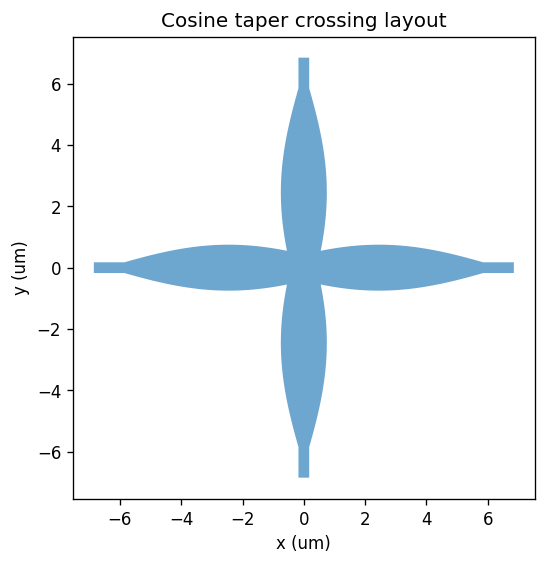

In [4]:
# numerically solve for the cosine function that describes the taper shape
def equations(x0):
    a, b = x0
    return (
        w_m * np.cos(a * (-w_out / 2) + b) - w_out / 2,
        w_m * np.cos(a * (-w_out / 2 - l_t) + b) - w_in / 2,
    )


a, b = fsolve(equations, (0.5 / um, 2.0))

x = np.linspace(-w_out / 2 - l_t, -w_out / 2, 30)
w = w_m * np.cos(a * x + b)

# Construct one taper, then generate the remaining three by symmetry.
vertices_left = list(zip(np.r_[x, x[::-1]], np.r_[w, -w[::-1]]))
vertices_right = [(-xv, yv) for xv, yv in vertices_left]
vertices_top = [(yv, -xv) for xv, yv in vertices_left]
vertices_bottom = [(yv, xv) for xv, yv in vertices_left]
taper_vertex_sets = (vertices_left, vertices_right, vertices_top, vertices_bottom)


def _iter_polygons(geometry):
    if geometry.geom_type == "Polygon":
        return [geometry]
    if geometry.geom_type == "MultiPolygon":
        return list(geometry.geoms)
    raise ValueError(f"Expected Polygon or MultiPolygon, got {geometry.geom_type}")


def _ring_vertices(ring, z0=-h / 2):
    return [(float(xv), float(yv), z0) for xv, yv in list(ring.coords)[:-1]]


def silicon_union_2d(domain_size):
    lx, ly = domain_size
    pieces = [ShapelyPolygon(verts) for verts in taper_vertex_sets]
    pieces.extend(
        [
            shapely_box(-w_out / 2, -w_out / 2, w_out / 2, w_out / 2),
            shapely_box(-lx / 2, -w_in / 2, lx / 2, w_in / 2),
            shapely_box(-w_in / 2, -ly / 2, w_in / 2, ly / 2),
        ]
    )
    merged = unary_union(pieces)
    return merged if merged.is_valid else merged.buffer(0)


def merged_silicon_structures(domain_size, z0=-h / 2):
    return [
        bz.Polygon(
            vertices=_ring_vertices(polygon.exterior, z0),
            interiors=[_ring_vertices(ring, z0) for ring in polygon.interiors],
            material=mat_si,
            depth=h,
            z=z0,
        )
        for polygon in _iter_polygons(silicon_union_2d(domain_size))
    ]


fig, ax = plt.subplots(figsize=(5, 5))
for polygon in _iter_polygons(silicon_union_2d((2 * l_t + w_out + 2 * l_wg, 2 * l_t + w_out + 2 * l_wg))):
    x_poly, y_poly = np.asarray(polygon.exterior.coords.xy) / um
    ax.fill(x_poly, y_poly, color="tab:blue", alpha=0.65, linewidth=0)
ax.set_aspect("equal")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("Cosine taper crossing layout")
plt.show()


Set up the simulation domain, source plane, and monitors. The source and flux planes use the original straight-section placement from the reference setup. The workflow is still: create an empty simulation, solve and inspect the local mode, then attach the mode source. The immutable `ModeSource` config owns the solve request, and BeamZ's native mode package handles solving and launch planning during preview and compilation.


In [5]:
lambda0 = 1.31 * um
freq0 = bz.LIGHT_SPEED / lambda0
ldas = np.linspace(1.26, 1.36, 5 if test_mode else 101)
lambdas = ldas * um
freqs = bz.LIGHT_SPEED / lambdas

fwidth = freq0 / 10
run_time = 6 / freq0 if test_mode else 1e-12

min_steps_per_wvl = 4 if test_mode else 10
dx = lambda0 / (min_steps_per_wvl * n_si)
grid_spec = bz.GridSpec.uniform(dx)


def snap_domain_to_grid(length, resolution):
    cells = int(np.ceil(length / resolution))
    # Nudge upward by one floating-point step so BEAMZ int(length / dx)
    # cannot truncate to cells - 1 because of roundoff.
    return np.nextafter(cells * resolution, np.inf), cells


Lxy_target = 2 * l_t + w_out + 2 * l_wg
Lx, nx = snap_domain_to_grid(Lxy_target, dx)
Ly, ny = snap_domain_to_grid(Lxy_target, dx)
Lz, nz = snap_domain_to_grid(1.5 * lambda0, dx)
sim_size = (Lx, Ly, Lz)

pml_layers = 4 if test_mode else 12
pml_t = pml_layers * lambda0 / (min_steps_per_wvl * n_si)
source_x = -Lx / 2 + l_wg / 2
through_x = Lx / 2 - l_wg / 2
cross_y = Ly / 2 - l_wg / 2

# Merge the center square, four tapers, and straight waveguides into one silicon
# polygon set before rasterization. Rasterizing one merged object avoids tiny
# anti-aliased seams where separate equal-material objects overlap or touch.
structures = merged_silicon_structures((Lx, Ly), z0=-h / 2)

source_time = bz.GaussianPulse(
    freq0=freq0,
    fwidth=fwidth,
    offset=0.5 if test_mode else 4.0,
)
mode_spec = bz.ModeSpec(num_modes=1, target_neff=3.455, polarization="te")
boundaries = (
    bz.PML(
        thickness=pml_t,
        formulation="cpml",
        m=3,
        kappa_max=3.0,
        alpha_max=0.0,
    ),
)

plane_z_span = 4 * h
source_plane = bz.Box(center=(source_x, 0, 0), size=(0, 4 * w_in, plane_z_span))

field_monitor = bz.FieldMonitor(
    center=(0.0, 0.0, 0.0),
    size=(Lx, Ly, 0.0),
    freqs=[freq0],
    fields=("Ex", "Ey", "Ez"),
    name="field",
)

flux_monitor_through = bz.FluxMonitor(
    center=(through_x, 0, 0),
    size=(0, 4 * w_in, plane_z_span),
    freqs=freqs,
    name="flux_through",
)

flux_monitor_cross = bz.FluxMonitor(
    center=(0, cross_y, 0),
    size=(4 * w_in, 0, plane_z_span),
    freqs=freqs,
    name="flux_cross",
)

design = bz.Design(background=mat_sio2)
for structure in structures:
    design += structure

sim0 = bz.Simulation(
    domain=sim_size,
    grid_spec=grid_spec,
    design=design,
    sources=[],
    monitors=[field_monitor, flux_monitor_through, flux_monitor_cross],
    boundaries=boundaries,
    run_time=run_time,
)

print(f"dx = {sim0.resolution / um:.4f} um")
grid_shape = sim0.to_request(num_steps=1, backend=backend).materials.shape
print(f"grid = {grid_shape}, steps = {sim0.num_steps}")
print(f"target Lx/Ly = {Lxy_target / um:.4f} um; snapped Lx/Ly = {Lx / um:.4f} um ({nx} cells)")
print(f"snapped Lz = {Lz / um:.4f} um ({nz} cells)")
print(f"source/monitor x/y clearance to domain edge = {l_wg / (2 * um):.2f} um")
print(f"CPML width = {pml_t / um:.3f} um ({pml_layers} cells at the reference grid)")
print(f"source/monitor clearance to x/y CPML = {(l_wg / 2 - pml_t) / um:.2f} um")
print(f"source/monitor clearance to z CPML = {(Lz / 2 - pml_t - plane_z_span / 2) / um:.2f} um")


dx = 0.0357 um
grid = (56, 384, 384), steps = 14695
target Lx/Ly = 13.7000 um; snapped Lx/Ly = 13.7068 um (384 cells)
snapped Lz = 1.9989 um (56 cells)
source/monitor x/y clearance to domain edge = 0.50 um
CPML width = 0.428 um (12 cells at the reference grid)
source/monitor clearance to x/y CPML = 0.07 um
source/monitor clearance to z CPML = 0.25 um


Solve the input waveguide modes on the source plane and convert the lowest-order TE-like mode into a BEAMZ mode source.

,,wavelength,n eff,k eff,loss (dB/cm),mode area
f,mode_index,,,,,
2.288492e+14,0,1.31,2.33626,0.0,0.0,0.130014


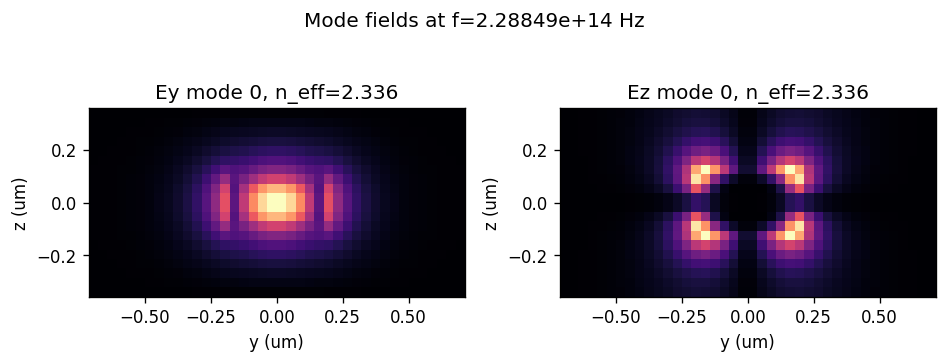

In [6]:
mode_source_request = bz.ModeSource(
    center=source_plane.center,
    size=source_plane.size,
    direction="+",
    source_time=source_time,
    mode_spec=mode_spec,
    power=1.0,
)
modes = mode_source_request.solve_modes(sim0, freqs=[freq0])

from beamz.analysis import mode_data_to_dataframe
from beamz.analysis.plotting import plot_mode_field_components
fig, axes, neffs = plot_mode_field_components(modes,
    field_names=("Ey", "Ez"),
    mode_indices=(0,),
    val="abs",
    f=freq0,
    figsize=(8, 3),
    show=False,
)
display(mode_data_to_dataframe(modes))
plt.show()

# Attach the same immutable ModeSource config after inspection. Compilation will
# lower it into a native launch plan without mutating this object.
mode_source = mode_source_request
sim = sim0.updated_copy(sources=(mode_source,))

Before running the simulation, plot the structure, source, and monitor planes to verify the setup. BEAMZ does not need a cloud job submission step; the simulation runs locally.

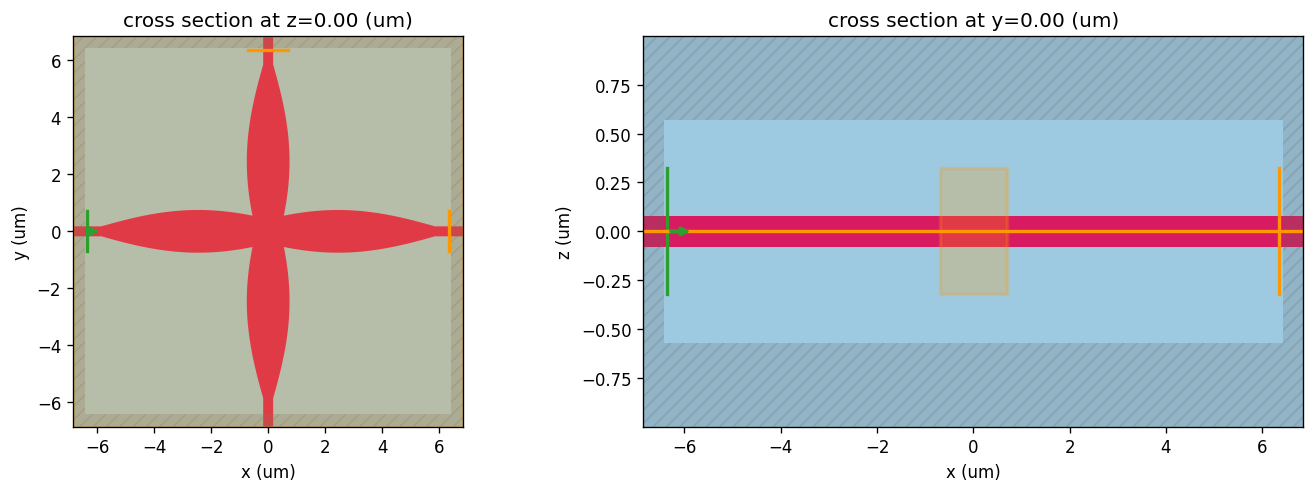

In [7]:
sim.plot(z=0, y=0, width_ratios=[1, 1.2])
plt.show()

Run the crossing at the practical 10-steps-per-wavelength grid. `ModeSource` calibrates its emitted power as part of launch compilation, and the detached flux results apply the source waveform normalization automatically. No reference or input monitor is required.

In [8]:
sim_data = sim.run(progress=True, backend=backend)

* Compiling simulation...
* Running simulation: [####################] 100% (14695/14695 steps)
Simulation runtime: 47.92 s
GCUPS: 2.532


## Result Visualization

After the simulation completes, first plot the field distribution at the crossing plane. A strong field focus near the junction indicates that the cosine taper is shaping the mode before it reaches the crossing center.

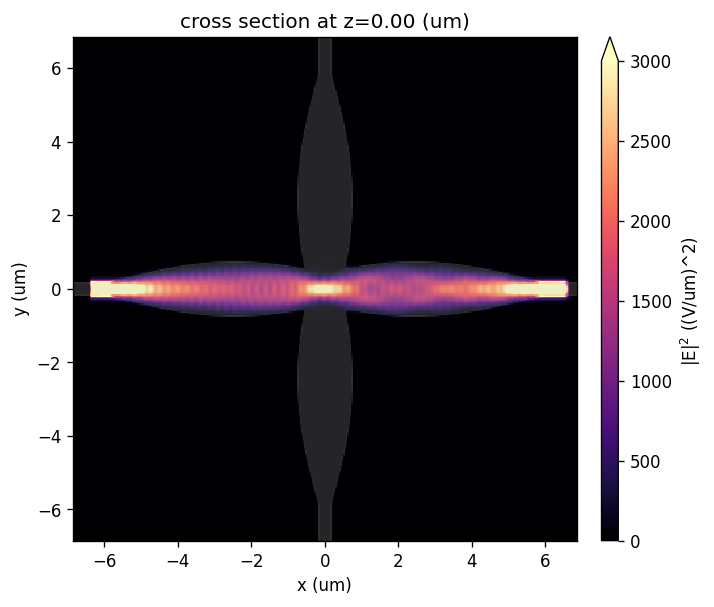

In [9]:
sim_data.plot_field(
    field_monitor_name="field",
    field_name="E",
    val="abs^2",
    f=freq0,
    vmin=0,
    vmax=3000,
    cmap="magma",
    figsize=(6, 5)
)
plt.show()

Finally, quantify the crossing performance over the O-band wavelength range. `FluxMonitor.flux` already includes the source waveform normalization and is reported in watts. The transmission denominator is `SimulationResults.launched_power()`: the solved source mode integrated with the mode solver's exact component-staggered transverse metric. The mode-source compiler uses that value to calibrate the launch to the requested 1 W, without adding an input monitor or reference simulation. Crosstalk is the cross-port power relative to through-port power. We plot `10 log10(T)`, which is negative for a passive device; positive insertion loss would instead use `-10 log10(T)`.

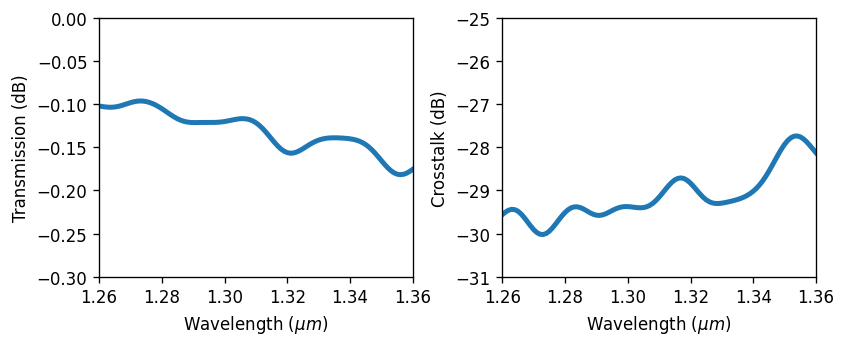

In [10]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(7, 3))

flux_through = sim_data["flux_through"].flux
flux_cross = sim_data["flux_cross"].flux
source_power = sim_data.launched_power(source=0)

def safe_power_ratio(numerator, denominator, floor=1e-30):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    ratio = np.zeros(np.broadcast_shapes(numerator.shape, denominator.shape), dtype=float)
    return np.divide(numerator, denominator, out=ratio, where=np.abs(denominator) >= floor)

T_through = safe_power_ratio(flux_through, source_power)
T_cross = safe_power_ratio(flux_cross, source_power)

transmission_db = 10 * np.log10(np.maximum(T_through, 1e-30))
crosstalk_db = 10 * np.log10(np.maximum(safe_power_ratio(T_cross, T_through), 1e-30))

ax1.plot(ldas, transmission_db, lw=3)
ax1.set_xlabel(r"Wavelength ($\mu m$)")
ax1.set_ylabel("Transmission (dB)")
ax1.set_xlim((1.26, 1.36))
ax1.set_ylim((-0.3, -0))

ax2.plot(ldas, crosstalk_db, lw=3)
ax2.set_xlabel(r"Wavelength ($\mu m$)")
ax2.set_ylabel("Crosstalk (dB)")
ax2.set_xlim((1.26, 1.36))
ax2.set_ylim((-31, -25))
plt.show()